In [1]:
# E-commerce Customer Behavior Analysis

In [2]:
# 1. Imports and display settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')

In [3]:
# 2. Load and check dataset
df = pd.read_excel('../data/online_retail.xlsx', sheet_name=0, engine='openpyxl')
print('Rows, cols:', df.shape)
df.head()

Rows, cols: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()
print('\nMissing values per column:\n', df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

Missing values per column:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [5]:
df['CustomerID'].isna().mean()

np.float64(0.249266943342886)

In [6]:
# 3. Initial cleaning

# Convert types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


# Remove negative or zero quantities
df = df[df['Quantity'] > 0]


# Remove negative or zero prices
df = df[df['UnitPrice'] > 0]


# Remove cancellations (InvoiceNo that starts with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]


# Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']


# Use only rows with CustomerID for customer-based analysis
customers_df = df.dropna(subset=['CustomerID']).copy()
customers_df['CustomerID'] = customers_df['CustomerID'].astype(int)


print('Cleaned rows, cols:', df.shape)

Cleaned rows, cols: (530104, 9)


In [7]:
# 4. Basic KPIs
n_orders = df['InvoiceNo'].nunique()
n_customers = df['CustomerID'].nunique()
total_revenue = df['Revenue'].sum()
avg_order_value = df.groupby('InvoiceNo')['Revenue'].sum().mean()


print(f"Orders: {n_orders}")
print(f"Unique customers: {n_customers}")
print(f"Total revenue: {total_revenue:.2f}")
print(f"Avg order value: {avg_order_value:.2f}")

Orders: 19960
Unique customers: 4338
Total revenue: 10666684.54
Avg order value: 534.40


In [8]:
df.groupby('InvoiceNo')['Revenue'].sum().max()

np.float64(168469.6)

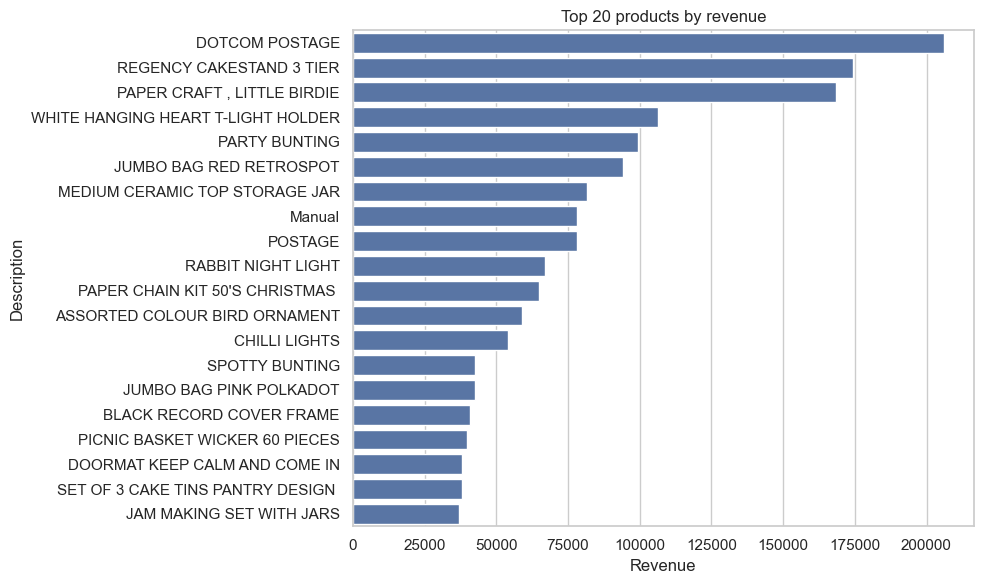

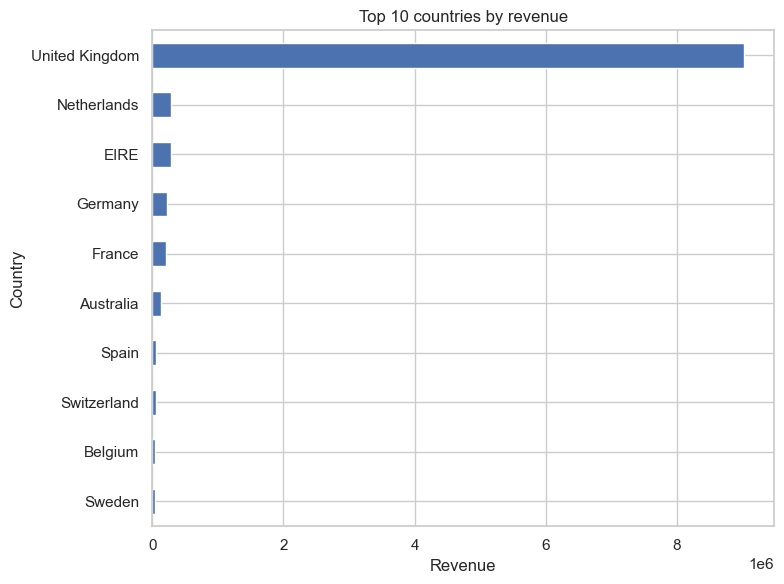

In [9]:
# 5. Top products and countries

# Top products by revenue
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title('Top 20 products by revenue')
plt.xlabel('Revenue')
plt.tight_layout()
plt.show()


# Top countries by revenue
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,6))
country_revenue.head(10).plot(kind='barh')
plt.title('Top 10 countries by revenue')
plt.xlabel('Revenue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

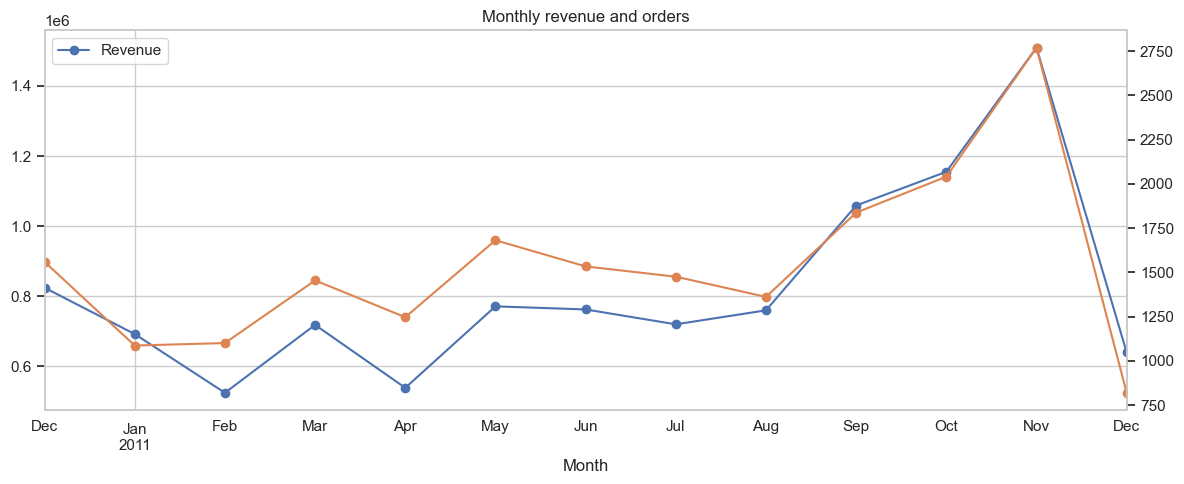

In [10]:
# 6. Time series: monthly revenue & orders

# Monthly aggregation
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M').dt.to_timestamp()
monthly = df.groupby('InvoiceMonth').agg({'Revenue':'sum', 'InvoiceNo':'nunique'}).rename(columns={'InvoiceNo':'Orders'})


fig, ax = plt.subplots(figsize=(12,5))
monthly['Revenue'].plot(ax=ax, marker='o', label='Revenue')
monthly['Orders'].plot(ax=ax, marker='o', label='Orders', secondary_y=True)
ax.set_title('Monthly revenue and orders')
ax.set_xlabel('Month')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [11]:
# 7. Customer-level metrics & simple LTV exploratory
cust = customers_df.groupby('CustomerID').agg({
'InvoiceDate': lambda x: (x.max() - x.min()).days,
'InvoiceNo': 'nunique',
'Revenue': 'sum'
})


cust.columns = ['CustomerActiveDays', 'NumOrders', 'TotalRevenue']
cust.describe()

,CustomerActiveDays,NumOrders,TotalRevenue
count,4338.000000,4338.000000,4338.000000
mean,130.448594,4.272015,2054.266460
std,132.039554,7.697998,8989.230441
min,0.000000,1.000000,3.750000
25%,0.000000,1.000000,307.415000
50%,92.500000,2.000000,674.485000
75%,251.750000,5.000000,1661.740000
max,373.000000,209.000000,280206.020000


In [12]:
# 8. RFM analysis

snapshot_date = df['InvoiceDate'].max() + timedelta(days=1)
rfm = customers_df.groupby('CustomerID').agg({
'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
'InvoiceNo': 'nunique',
'Revenue': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']


# R, F, M scoring (1-4)
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4]).astype(int)


rfm['RFM_Score'] = rfm['R_score'].map(str) + rfm['F_score'].map(str) + rfm['M_score'].map(str)
rfm['RFM_sum'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']


# Top customers
top_segment = rfm[rfm['RFM_sum'] >= 10].sort_values('RFM_sum', ascending=False)
print('Top customers count:', top_segment.shape[0])
top_segment.head()

Top customers count: 1268


,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,RFM_sum
CustomerID,,,,,,,,
18283,4,16,2094.88,4,4,4,444,12
12347,2,7,4310.00,4,4,4,444,12
18272,3,6,3078.58,4,4,4,444,12
18245,7,7,2567.06,4,4,4,444,12
12362,3,10,5226.23,4,4,4,444,12


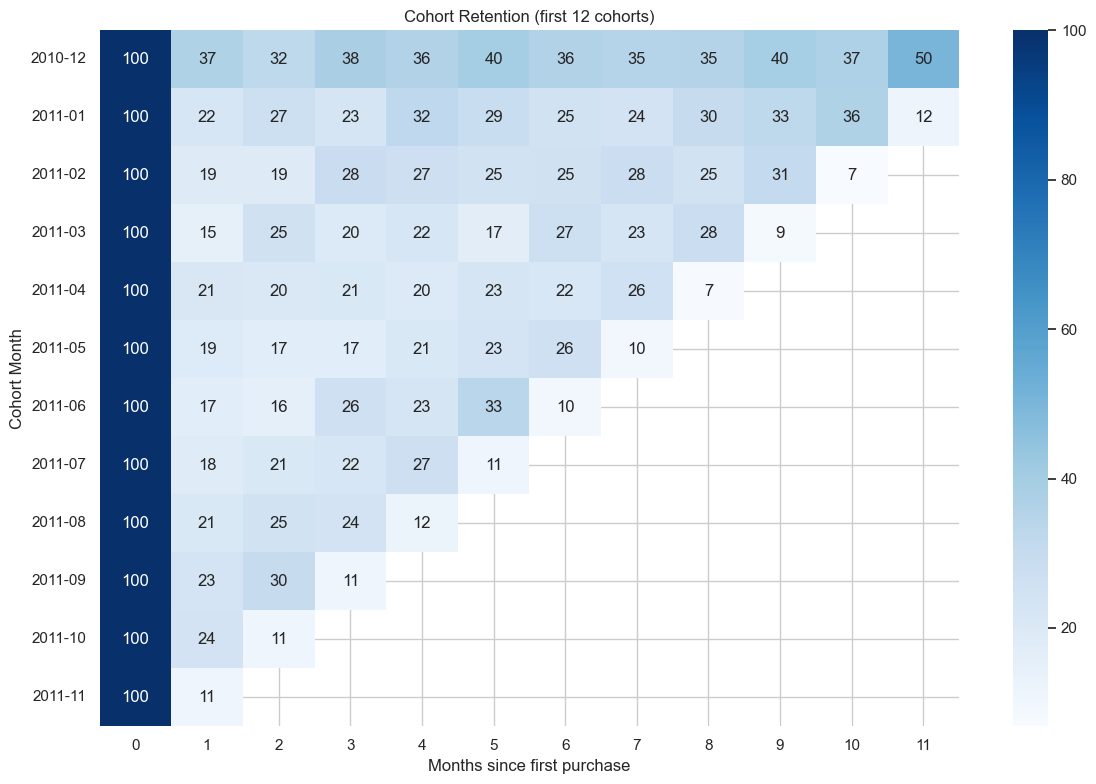

In [14]:
# 9. Cohort Retention

# Convert InvoiceDate to datetime
customers_df['InvoiceDate'] = pd.to_datetime(customers_df['InvoiceDate'])

# Create month periods
customers_df['OrderMonth'] = customers_df['InvoiceDate'].dt.to_period('M')
customers_df['CohortMonth'] = customers_df.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')

# Count unique customers
cohort_data = customers_df.groupby(['CohortMonth','OrderMonth']).agg({'CustomerID':'nunique'}).reset_index()

# Calculate months since first purchase
cohort_data['CohortPeriod'] = (cohort_data['OrderMonth'].dt.year - cohort_data['CohortMonth'].dt.year) * 12 + \
                               (cohort_data['OrderMonth'].dt.month - cohort_data['CohortMonth'].dt.month)

# Pivot
cohort_counts = cohort_data.pivot_table(index='CohortMonth', columns='CohortPeriod', values='CustomerID')

# Retention
cohort_sizes = cohort_counts.iloc[:,0]
retention = cohort_counts.divide(cohort_sizes, axis=0)

# Convert CohortMonth to string for display
cohort_counts.index = cohort_counts.index.astype(str)

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(retention.iloc[:12, :12]*100, annot=True, fmt='.0f', cmap='Blues')
plt.title('Cohort Retention (first 12 cohorts)')
plt.ylabel('Cohort Month')
plt.xlabel('Months since first purchase')
plt.tight_layout()
plt.show()
